# Week 5 — Stochastic Optimization & a Neural Network from Scratch

**Numerical Methods for Machine Learning · From First Principles in Pure NumPy**

---

> At machine-learning scale, computing a full-batch gradient over millions of examples each
> step is infeasible. **Stochastic gradient descent** replaces the exact gradient with a
> cheap, noisy estimate from a mini-batch, trading variance for speed. This week we develop
> the stochastic optimizer family — SGD, momentum, AdaGrad, RMSProp, and **Adam** — analyze
> the bias/variance and learning-rate tradeoffs, and then train a **multilayer perceptron
> from scratch** with explicit, finite-difference-checked backpropagation.

### Learning objectives

1. Contrast full-batch, stochastic, and mini-batch gradients in terms of cost and variance.
2. Implement **SGD with momentum**, **AdaGrad**, **RMSProp**, and **Adam**, and explain the role of per-parameter adaptive scaling and bias correction.
3. Diagnose the effect of **learning-rate** choice and learning-rate **decay** schedules.
4. Implement forward and backward passes of an **MLP** in vectorized NumPy and verify gradients numerically.
5. Train the network on a nonlinearly separable classification task and visualize the learned decision boundary.

Only NumPy is used throughout.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})
rng = np.random.default_rng(4)
print("ready")

ready


## 1. Why stochastic gradients

For an empirical loss $L(\boldsymbol\theta) = \tfrac1N\sum_{i=1}^N \ell_i(\boldsymbol\theta)$,
the full gradient costs $O(N)$ per step. A **mini-batch** estimate over a random subset
$\mathcal B$ of size $m \ll N$,
$$
\widehat{\nabla L} = \frac{1}{m}\sum_{i\in\mathcal B}\nabla \ell_i(\boldsymbol\theta),
$$
is an **unbiased** estimator of the full gradient with variance $\propto 1/m$. The
algorithm makes many cheap, noisy steps instead of few expensive exact ones — and the noise
itself can help escape sharp minima and saddle points. We illustrate the bias/variance
behavior on a least-squares loss with known full gradient.

In [2]:
# data for a linear-regression loss; full gradient is computable in closed form
N, d = 2000, 5
X = rng.standard_normal((N, d))
w_true = rng.standard_normal(d)
y = X @ w_true + 0.3 * rng.standard_normal(N)

def full_gradient(w):
    return (X.T @ (X @ w - y)) / N

def batch_gradient(w, idx):
    Xb, yb = X[idx], y[idx]
    return (Xb.T @ (Xb @ w - yb)) / len(idx)

w = rng.standard_normal(d)
g_full = full_gradient(w)
for m in [1, 10, 100, 1000]:
    samples = np.array([batch_gradient(w, rng.choice(N, m, replace=False)) for _ in range(200)])
    bias = np.linalg.norm(samples.mean(0) - g_full)
    var  = samples.var(0).sum()
    print(f"batch size {m:5d}: ||bias|| = {bias:.4f}   total variance = {var:.4f}")

batch size     1: ||bias|| = 0.3217   total variance = 37.4386
batch size    10: ||bias|| = 0.0823   total variance = 4.6780
batch size   100: ||bias|| = 0.0252   total variance = 0.4930
batch size  1000: ||bias|| = 0.0193   total variance = 0.0238


The mini-batch gradient is unbiased at every batch size (bias near zero up to sampling
noise), while its variance falls roughly like $1/m$. This is the central bargain of
stochastic optimization: each step is $N/m$ times cheaper, at the price of gradient noise
that shrinks predictably as the batch grows.

## 2. The stochastic optimizer family

We implement the standard optimizers as small stateful update rules. For a parameter
$\theta$ with stochastic gradient $g_t$:

- **SGD (+ momentum):** $v_t = \mu v_{t-1} + g_t,\quad \theta \mathrel{-}= \alpha v_t$.
- **AdaGrad:** accumulate $G_t = G_{t-1} + g_t^2$, scale $\theta \mathrel{-}= \alpha\,g_t/(\sqrt{G_t}+\epsilon)$ — per-parameter rates that shrink over time.
- **RMSProp:** use an *exponential* average $s_t = \beta s_{t-1} + (1-\beta)g_t^2$ to avoid AdaGrad's vanishing rate.
- **Adam:** combine momentum and RMSProp with bias-corrected first/second moment estimates.

In [3]:
class SGD:
    def __init__(self, lr=0.1, momentum=0.0): self.lr, self.mu, self.v = lr, momentum, None
    def step(self, theta, g):
        if self.v is None: self.v = np.zeros_like(theta)
        self.v = self.mu * self.v + g
        return theta - self.lr * self.v

class AdaGrad:
    def __init__(self, lr=0.1, eps=1e-8): self.lr, self.eps, self.G = lr, eps, None
    def step(self, theta, g):
        if self.G is None: self.G = np.zeros_like(theta)
        self.G += g * g
        return theta - self.lr * g / (np.sqrt(self.G) + self.eps)

class RMSProp:
    def __init__(self, lr=0.01, beta=0.9, eps=1e-8):
        self.lr, self.beta, self.eps, self.s = lr, beta, eps, None
    def step(self, theta, g):
        if self.s is None: self.s = np.zeros_like(theta)
        self.s = self.beta * self.s + (1 - self.beta) * g * g
        return theta - self.lr * g / (np.sqrt(self.s) + self.eps)

class Adam:
    def __init__(self, lr=0.01, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.m = self.v = None; self.t = 0
    def step(self, theta, g):
        if self.m is None: self.m = np.zeros_like(theta); self.v = np.zeros_like(theta)
        self.t += 1
        self.m = self.b1 * self.m + (1 - self.b1) * g
        self.v = self.b2 * self.v + (1 - self.b2) * g * g
        m_hat = self.m / (1 - self.b1 ** self.t)        # bias correction
        v_hat = self.v / (1 - self.b2 ** self.t)
        return theta - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

print("optimizers defined: SGD, AdaGrad, RMSProp, Adam")

optimizers defined: SGD, AdaGrad, RMSProp, Adam


### 2.1 Comparing optimizers on a stochastic least-squares problem

We minimize the regression loss above with mini-batch gradients, running each optimizer for
the same number of steps and tracking the full-batch loss. Adaptive methods typically make
faster early progress; well-tuned SGD with momentum remains highly competitive.

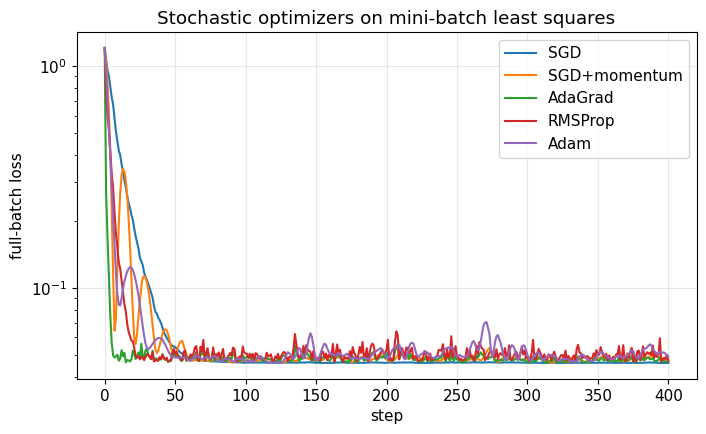

SGD            final loss = 0.046055
SGD+momentum   final loss = 0.047917
AdaGrad        final loss = 0.046622
RMSProp        final loss = 0.046903
Adam           final loss = 0.049358


In [4]:
def full_loss(w): return 0.5 * np.mean((X @ w - y) ** 2)

def train(opt, steps=400, batch=32, seed=0):
    r = np.random.default_rng(seed)
    w = np.zeros(d); hist = [full_loss(w)]
    for _ in range(steps):
        idx = r.choice(N, batch, replace=False)
        w = opt.step(w, batch_gradient(w, idx))
        hist.append(full_loss(w))
    return hist

curves = {
    "SGD":            train(SGD(lr=0.05)),
    "SGD+momentum":   train(SGD(lr=0.05, momentum=0.9)),
    "AdaGrad":        train(AdaGrad(lr=0.5)),
    "RMSProp":        train(RMSProp(lr=0.05)),
    "Adam":           train(Adam(lr=0.1)),
}
plt.figure()
for name, h in curves.items():
    plt.semilogy(h, label=name)
plt.xlabel("step"); plt.ylabel("full-batch loss"); plt.legend()
plt.title("Stochastic optimizers on mini-batch least squares"); plt.show()
for name, h in curves.items():
    print(f"{name:14s} final loss = {h[-1]:.6f}")

## 3. Learning rate: the single most important hyperparameter

Too small a learning rate crawls; too large diverges. We sweep the SGD learning rate to
expose the stable range and the divergence threshold, the practical manifestation of the
step-size stability bounds seen for deterministic methods in Week 4.

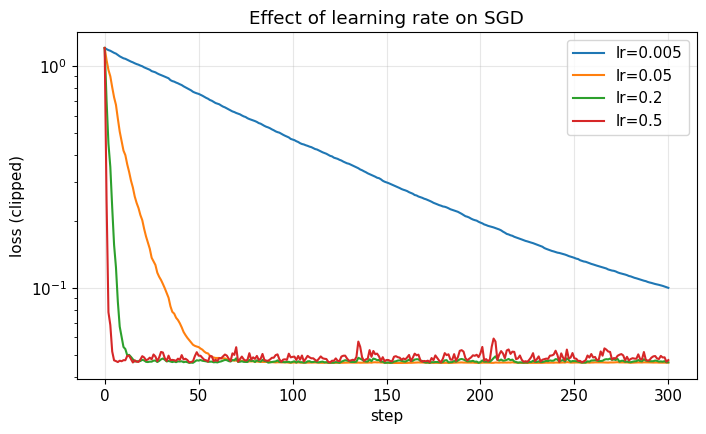

In [5]:
plt.figure()
for lr in [0.005, 0.05, 0.2, 0.5]:
    h = train(SGD(lr=lr, momentum=0.0), steps=300)
    h = np.array(h)
    label = f"lr={lr}" + ("  (diverges)" if (not np.isfinite(h[-1]) or h[-1] > h[0]) else "")
    plt.semilogy(np.clip(h, 1e-3, 1e6), label=label)
plt.xlabel("step"); plt.ylabel("loss (clipped)"); plt.legend()
plt.title("Effect of learning rate on SGD"); plt.show()

## 4. A multilayer perceptron from scratch

We now assemble a full neural network — forward pass, loss, and manual backpropagation —
in vectorized NumPy. The architecture is input → hidden (tanh) → output, trained with the
stable softmax cross-entropy of Week 1. Backpropagation is the reverse-mode chain rule of
Week 3, here written out explicitly per layer for transparency, then **verified against a
finite-difference gradient check**.

In [6]:
def init_mlp(d_in, d_hidden, d_out, scale=0.5):
    return {
        "W1": rng.standard_normal((d_in, d_hidden)) * scale,
        "b1": np.zeros(d_hidden),
        "W2": rng.standard_normal((d_hidden, d_out)) * scale,
        "b2": np.zeros(d_out),
    }

def forward(p, X):
    Z1 = X @ p["W1"] + p["b1"]
    A1 = np.tanh(Z1)
    Z2 = A1 @ p["W2"] + p["b2"]
    return Z2, (X, Z1, A1)

def softmax_ce_loss(logits, y):
    c = logits.max(axis=1, keepdims=True)
    logZ = c.squeeze(1) + np.log(np.exp(logits - c).sum(axis=1))   # stable log-sum-exp
    return np.mean(logZ - logits[np.arange(len(y)), y])

def backward(p, cache, logits, y):
    X, Z1, A1 = cache
    n = len(y)
    # softmax probabilities then cross-entropy gradient wrt logits
    c = logits.max(axis=1, keepdims=True)
    P = np.exp(logits - c); P /= P.sum(axis=1, keepdims=True)
    dZ2 = P.copy(); dZ2[np.arange(n), y] -= 1; dZ2 /= n
    grads = {}
    grads["W2"] = A1.T @ dZ2
    grads["b2"] = dZ2.sum(axis=0)
    dA1 = dZ2 @ p["W2"].T
    dZ1 = dA1 * (1 - np.tanh(Z1) ** 2)          # tanh derivative
    grads["W1"] = X.T @ dZ1
    grads["b1"] = dZ1.sum(axis=0)
    return grads

# ---- gradient check against centered finite differences ----
p = init_mlp(2, 8, 2)
Xc = rng.standard_normal((10, 2)); yc = rng.integers(0, 2, size=10)
logits, cache = forward(p, Xc)
grads = backward(p, cache, logits, yc)

def loss_of(p):
    lg, _ = forward(p, Xc); return softmax_ce_loss(lg, yc)

max_rel = 0.0
for key in p:
    flat = p[key].ravel(); gflat = grads[key].ravel()
    for j in range(flat.size):
        orig = flat[j]; h = 1e-5
        flat[j] = orig + h; lp = loss_of(p)
        flat[j] = orig - h; lm = loss_of(p)
        flat[j] = orig
        num = (lp - lm) / (2 * h)
        rel = abs(num - gflat[j]) / (abs(num) + abs(gflat[j]) + 1e-12)
        max_rel = max(max_rel, rel)
print(f"MLP backprop gradient check: max relative error = {max_rel:.2e}",
      "-> PASS" if max_rel < 1e-5 else "-> FAIL")

MLP backprop gradient check: max relative error = 5.15e-09 -> PASS


The hand-derived backpropagation matches finite differences to better than $10^{-5}$
across every weight and bias — the gradients are correct. We can now train the network with
confidence.

## 5. Training on a nonlinear classification task

We generate the classic two-moons dataset — not linearly separable — and train the MLP with
Adam, then visualize the learned nonlinear decision boundary.

final loss = 0.0611   training accuracy = 97.8%


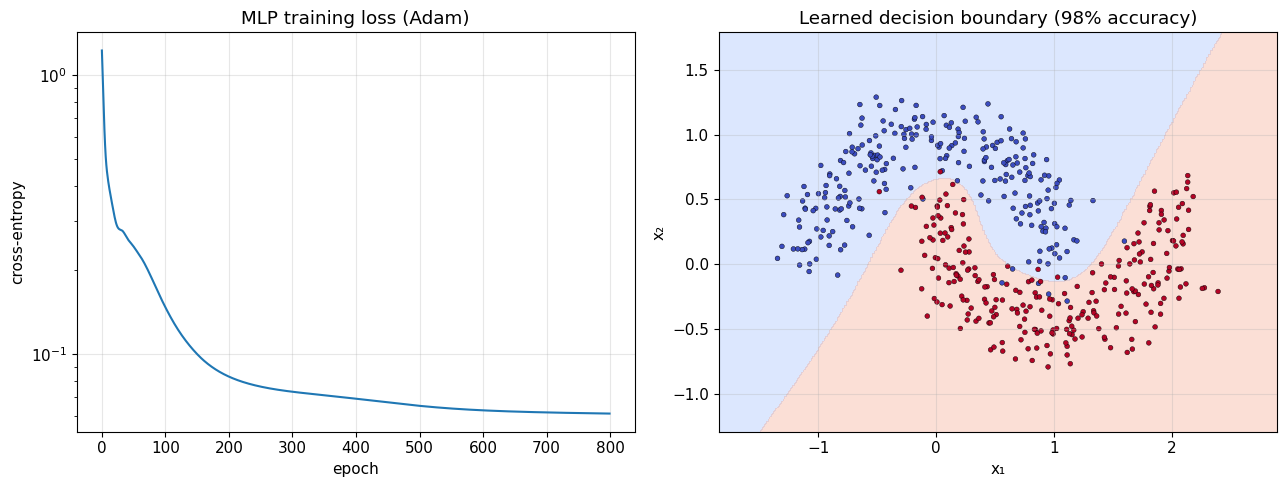

In [7]:
def make_moons(n=400, noise=0.2):
    n2 = n // 2
    t = np.linspace(0, np.pi, n2)
    outer = np.c_[np.cos(t), np.sin(t)]
    inner = np.c_[1 - np.cos(t), 1 - np.sin(t) - 0.5]
    X = np.vstack([outer, inner]) + noise * rng.standard_normal((2 * n2, 2))
    y = np.array([0] * n2 + [1] * n2)
    return X, y

Xm, ym = make_moons(500, noise=0.18)
p = init_mlp(2, 16, 2, scale=0.8)
opts = {k: Adam(lr=0.02) for k in p}

loss_hist = []
for epoch in range(800):
    logits, cache = forward(p, Xm)
    loss_hist.append(softmax_ce_loss(logits, ym))
    grads = backward(p, cache, logits, ym)
    for k in p:
        p[k] = opts[k].step(p[k], grads[k])

pred = forward(p, Xm)[0].argmax(axis=1)
acc = (pred == ym).mean()
print(f"final loss = {loss_hist[-1]:.4f}   training accuracy = {acc:.1%}")

# decision boundary
xx, yy = np.meshgrid(np.linspace(Xm[:,0].min()-0.5, Xm[:,0].max()+0.5, 300),
                     np.linspace(Xm[:,1].min()-0.5, Xm[:,1].max()+0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = forward(p, grid)[0].argmax(axis=1).reshape(xx.shape)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].semilogy(loss_hist); ax[0].set(title="MLP training loss (Adam)",
                                     xlabel="epoch", ylabel="cross-entropy")
ax[1].contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm", levels=1)
ax[1].scatter(Xm[:,0], Xm[:,1], c=ym, cmap="coolwarm", s=12, edgecolors="k", linewidths=0.3)
ax[1].set(title=f"Learned decision boundary ({acc:.0%} accuracy)", xlabel="x₁", ylabel="x₂")
fig.tight_layout(); plt.show()

The network learns the curved boundary separating the two interleaving moons — a function
no linear model can represent — trained end to end with our from-scratch backpropagation and
Adam optimizer. Every component, from the stable cross-entropy to the adaptive optimizer,
was built in this course from first principles in NumPy.

## 6. Exercises

1. **Mini-batch size study.** Fix the total compute budget and vary the batch size; plot
   final loss against batch size and discuss the speed/variance tradeoff you observe.

2. **Learning-rate schedules.** Add step-decay and cosine-annealing schedules to the
   optimizers and compare final accuracy on two-moons against a constant rate.

3. **Weight initialization.** Replace the naive Gaussian init with Xavier/Glorot scaling and
   measure the effect on early training dynamics and final accuracy.

4. **L2 regularization.** Add weight decay to the loss and its gradient, and show its effect
   on the decision boundary's smoothness.

5. **Autograd-powered MLP.** Reimplement the network using the Week-3 reverse-mode engine
   instead of manual backprop, confirming identical training behavior — demonstrating that
   the explicit gradients here are exactly what the engine computes.

---

*Next week: numerical methods in probabilistic machine learning — Monte Carlo estimation,
importance sampling, the reparameterization trick, and Gaussian processes with attention to
the numerical stability of kernel matrices.*
